# Customer Segmentation —  Project 3

## Unsupervised Learning | K-Means + PCA

**Project goal:** discover hidden customer groups in unlabeled retail data and translate the clusters into actionable business personas.

This follows the Project 3 requirements: **PCA dimensionality reduction**, **Elbow Method**, **Silhouette Score**, **K-Means clustering**, and **business persona interpretation**. 

The project brief specifically requires reducing 20+ columns to 2 or 3 PCA dimensions and mathematically supporting the optimal number of K-Means clusters. 


## Step 0 — Project roadmap

1. Import libraries
2. Load the internship Excel dataset
3. Understand the dataset
4. Clean missing values and duplicate rows
5. Select numerical customer features
6. Standardize features because K-Means is distance-based
7. Find the best K using the Elbow Method and Silhouette Score
8. Train the final K-Means model
9. Apply PCA and visualize customers in 2D
10. Profile each cluster
11. Translate clusters into business personas
12. Export the final segmented customer dataset


In [2]:
# Step 1 — Import required libraries
# These libraries cover data handling, visualization and machine learning.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [18]:
# Step 2 — Load the csv dataset


cs = pd.read_csv('Dataset for Data Analytics - Sheet1.csv')


display(cs.head())


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [19]:
# Check Shape
cs.shape

(1200, 14)

In [20]:
cs.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [21]:
cs.dtypes

OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object

In [22]:
# check missing value
cs.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [23]:
#Check dupicates v
print('\nDuplicate rows:', cs.duplicated().sum())


Duplicate rows: 0


In [29]:
# Step 4 — Clean the dataset
# Remove exact duplicate rows and keep a copy for reproducibility.

cs = cs.copy()
before = len(cs)
cs = cs.drop_duplicates().reset_index(drop=True)
print(f'Removed {before - len(cs)} duplicate rows.')

# Convert boolean columns to integers when present.
bool_cols = cs.select_dtypes(include=['bool']).columns.tolist()
for col in bool_cols:
    cs[col] = cs[col].astype(int)

print('Cleaned shape:', cs.shape)


Removed 0 duplicate rows.
Cleaned shape: (1200, 14)


In [30]:
# Step 5 — Select numerical customer features
# K-Means works with numerical feature vectors.
# We exclude obvious ID/index columns because an ID is an identifier, not customer behavior.

numeric_cols = cs.select_dtypes(include=np.number).columns.tolist()

id_like_cols = []
for col in numeric_cols:
    name = str(col).lower().replace('_', ' ').replace('-', ' ')
    if name in {'id', 'customer id', 'customerid', 'index', 'unnamed 0'} or name.endswith(' id'):
        id_like_cols.append(col)

feature_cols = [c for c in numeric_cols if c not in id_like_cols]

print('Numeric columns:', len(numeric_cols))
print('Excluded ID-like columns:', id_like_cols)
print('Candidate clustering features:', len(feature_cols))
print(feature_cols)

if len(feature_cols) < 2:
    raise ValueError('At least two numerical customer features are required for clustering.')


Numeric columns: 4
Excluded ID-like columns: []
Candidate clustering features: 4
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']


In [31]:
# Step 6 — Handle missing numeric values
# Median imputation is a simple robust approach for numerical features.

X = cs[feature_cols].copy()

missing_before = X.isna().sum().sum()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print('Missing/invalid numeric values handled:', missing_before)
print('Remaining missing values:', X.isna().sum().sum())


Missing/invalid numeric values handled: 0
Remaining missing values: 0


## Step 7 — Standardize the features

K-Means uses distances between observations. If one feature has a much larger numerical scale than another, it can dominate the clustering. Standardization puts features onto a comparable scale.

In [32]:
# StandardScaler transforms each feature approximately to mean=0 and standard deviation=1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)
display(X_scaled_df.head())


,Quantity,UnitPrice,ItemsInCart,TotalPrice
0,1.459993,1.086822,0.664173,2.195362
1,-0.672248,-1.040426,-1.089419,-0.916723
2,1.459993,0.985653,1.102571,2.073705
3,-1.382995,-0.422247,-0.212623,-0.952732
4,0.749246,1.367855,1.102571,1.769427


## Step 8 — Elbow Method

We train K-Means for several values of K and record **inertia** (within-cluster sum of squared distances). The elbow is the point where adding more clusters gives diminishing improvement.

In [33]:
# Try a practical range of K values.
max_k = min(10, len(cs) - 1)
k_values = range(2, max_k + 1)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))


  File "C:\Users\ADMiN\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ADMiN\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMiN\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMiN\anaconda3\Lib\subprocess.

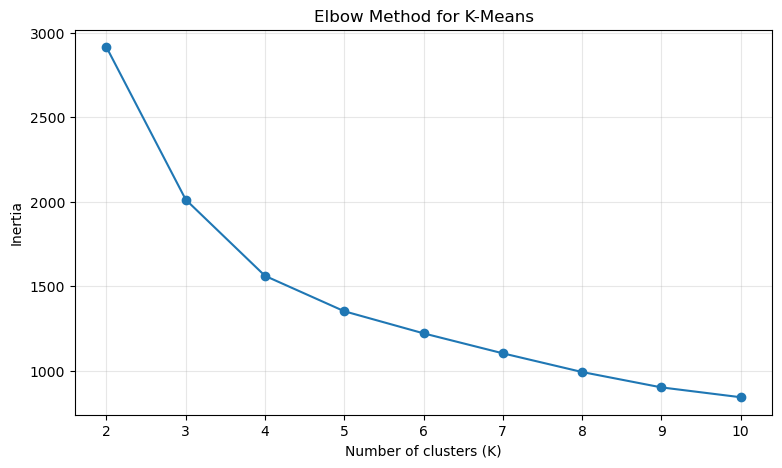

In [34]:
# Plot the Elbow curve.
plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()


## Step 9 — Silhouette Score

The Silhouette Score measures how well-separated and internally cohesive the clusters are. Higher values generally indicate better-defined clusters.

,K,Inertia,Silhouette Score
1,3,2011.736763,0.349820
0,2,2913.516130,0.344019
2,4,1561.005514,0.332802
3,5,1351.520565,0.308251
7,9,901.115619,0.292552
4,6,1220.801987,0.285848
8,10,842.875051,0.284676
6,8,992.017767,0.281672
5,7,1102.671017,0.278005


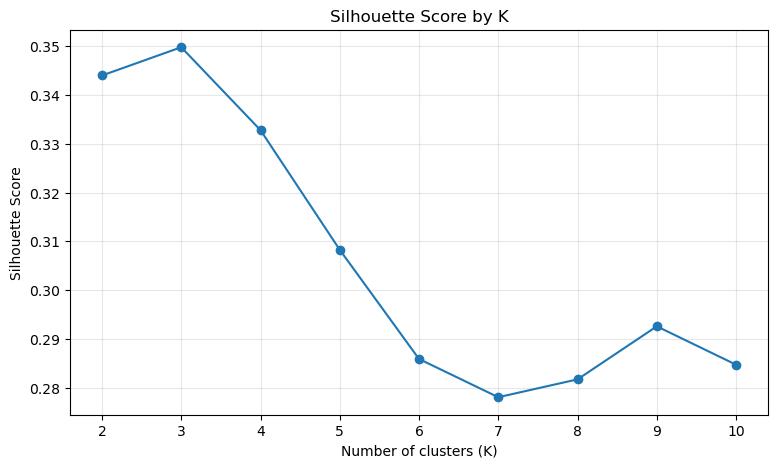

In [35]:
# Compare silhouette scores for every tested K.
evaluation = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})

display(evaluation.sort_values('Silhouette Score', ascending=False))

plt.figure(figsize=(9, 5))
plt.plot(evaluation['K'], evaluation['Silhouette Score'], marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()


### Choose the final K

The silhouette score gives a quantitative recommendation. **Do not blindly use the maximum score** if the Elbow curve clearly suggests a nearby, simpler solution. Inspect both plots and set `FINAL_K` below. The default is the K with the highest silhouette score.

In [41]:
# Recommended K from the highest silhouette score.
recommended_k = int(evaluation.loc[evaluation['Silhouette Score'].idxmax(), 'K'])

# You can manually change this after inspecting both plots.
FINAL_K = recommended_k

print('Recommended K from Silhouette Score:', recommended_k)
print('Final K used by this notebook:', FINAL_K)


Recommended K from Silhouette Score: 3
Final K used by this notebook: 3


## Step 10 — Train the final K-Means model

In [42]:
# Fit the final clustering model using the selected K.
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
cs['Cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, cs['Cluster'])
        
print('Final K:', FINAL_K)
print('Final Silhouette Score:', round(final_silhouette, 4))
print('\nCustomers per cluster:')
print(cs['Cluster'].value_counts().sort_index())


Final K: 3
Final Silhouette Score: 0.3498

Customers per cluster:
Cluster
0    306
1    348
2    546
Name: count, dtype: int64


## Step 11 — PCA dimensionality reduction

The internship brief asks for PCA to reduce 20+ columns into 2 or 3 dimensions for visualization. fileciteturn0file0L35-L44

We fit PCA on the **standardized feature matrix**, then visualize the resulting customer clusters in two dimensions.

In [43]:
# Reduce all standardized customer features to 2 principal components.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_cs = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=cs.index)
pca_cs['Cluster'] = cs['Cluster']

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total variance explained by 2 PCs:', round(pca.explained_variance_ratio_.sum(), 4))


Explained variance ratio: [0.56583157 0.32255633]
Total variance explained by 2 PCs: 0.8884


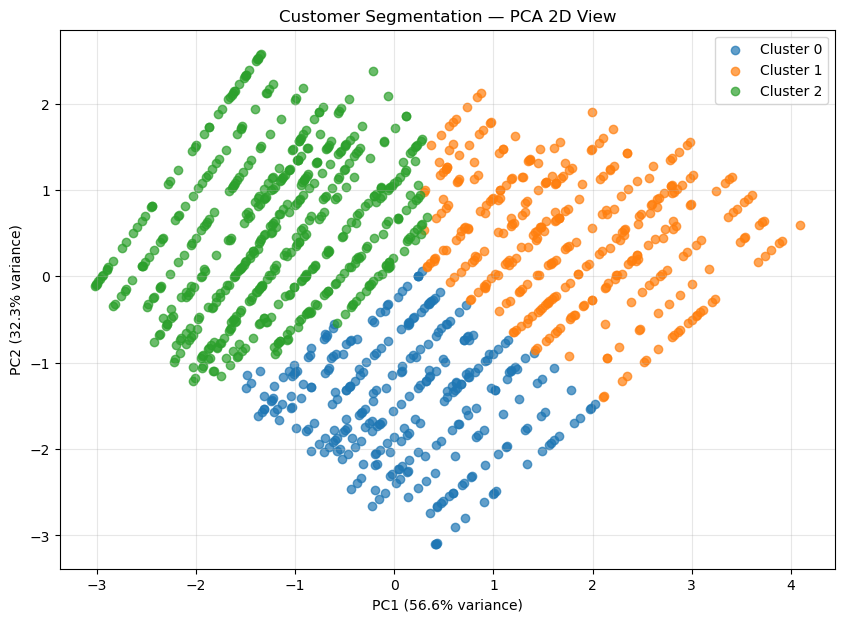

In [44]:
# 2D PCA visualization of the customer segments.
plt.figure(figsize=(10, 7))
for cluster in sorted(pca_cs['Cluster'].unique()):
    subset = pca_df[pca_cs['Cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer Segmentation — PCA 2D View')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Step 12 — Cluster profiling

Clustering becomes useful when we understand what makes each segment different. We compare the average values of the original numerical features for each cluster.

In [45]:
# Average original feature values by cluster.
cluster_profile = cs.groupby('Cluster')[feature_cols].mean().round(2)
        
print('Cluster profile — mean values:')
display(cluster_profile)


Cluster profile — mean values:


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Cluster,,,,
0,3.97,173.56,7.07,687.68
1,4.04,534.65,6.78,2135.89
2,1.68,345.29,3.77,569.68


In [46]:
# Show cluster sizes and percentages.
cluster_size = cs['Cluster'].value_counts().sort_index().to_frame('Customers')
cluster_size['Percentage'] = (cluster_size['Customers'] / len(cs) * 100).round(2)
        
print('Cluster size:')
display(cluster_size)


Cluster size:


,Customers,Percentage
Cluster,,
0,306,25.5
1,348,29.0
2,546,45.5


## Step 13 — Automatically identify high/low feature patterns

For easier business interpretation, compare each cluster's feature means against the overall mean. Positive values mean the cluster is above the overall average; negative values mean it is below average.

In [47]:
# Z-like interpretation table using cluster means relative to overall means.
overall_mean = X.mean()
overall_std = X.std().replace(0, np.nan)
cluster_relative = ((cluster_profile - overall_mean) / overall_std).round(2)

print('Relative cluster profile (positive = above average, negative = below average):')
display(cluster_relative)


Relative cluster profile (positive = above average, negative = below average):


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Cluster,,,,
0,0.73,-0.93,0.69,-0.45
1,0.78,0.90,0.57,1.32
2,-0.90,-0.06,-0.75,-0.59


## Step 14 — Business personas

The project brief requires translating mathematical clusters into actionable business **Personas**. **filecite** **turn0file0** **L42-L50**

The exact persona names must be based on the actual feature meanings in the dataset. Use the table above to identify each cluster's strongest positive and negative features, then document the business meaning below. Do not invent customer behavior that the dataset does not measure.

In [48]:
# Helper: list the strongest above/below-average features for every cluster.
for cluster in cluster_relative.index:
    row = cluster_relative.loc[cluster].dropna()
    high = row.sort_values(ascending=False).head(5)
    low = row.sort_values().head(5)
        
    print(f'\n===== Cluster {cluster} =====')
    print('Strongest above-average features:')
    print(high.to_string())
    print('\nStrongest below-average features:')
    print(low.to_string())



===== Cluster 0 =====
Strongest above-average features:
Quantity       0.73
ItemsInCart    0.69
TotalPrice    -0.45
UnitPrice     -0.93

Strongest below-average features:
UnitPrice     -0.93
TotalPrice    -0.45
ItemsInCart    0.69
Quantity       0.73

===== Cluster 1 =====
Strongest above-average features:
TotalPrice     1.32
UnitPrice      0.90
Quantity       0.78
ItemsInCart    0.57

Strongest below-average features:
ItemsInCart    0.57
Quantity       0.78
UnitPrice      0.90
TotalPrice     1.32

===== Cluster 2 =====
Strongest above-average features:
UnitPrice     -0.06
TotalPrice    -0.59
ItemsInCart   -0.75
Quantity      -0.90

Strongest below-average features:
Quantity      -0.90
ItemsInCart   -0.75
TotalPrice    -0.59
UnitPrice     -0.06


### Persona template

| Cluster | Persona name | Evidence from data | Suggested business action |
|---|---|---|---|
| Cluster 0 | Fill after profiling | Highest/lowest relevant features | Marketing/retention action |
| Cluster 1 | Fill after profiling | Highest/lowest relevant features | Marketing/retention action |
| Cluster 2 | Fill after profiling | Highest/lowest relevant features | Marketing/retention action |
| ... | Add rows if needed | Use actual dataset evidence | Keep actions tied to measured features |

**Important:** Persona labels such as “high-value loyal customer” should only be used when the dataset contains features that support that interpretation (for example, spending, purchase frequency, recency, or similar variables).

## Step 15 — Optional 3D PCA visualization

The project brief allows 2 or 3 PCA dimensions. **filecite** **turn0file0** **L38-L44** This optional section creates a 3D visualization 

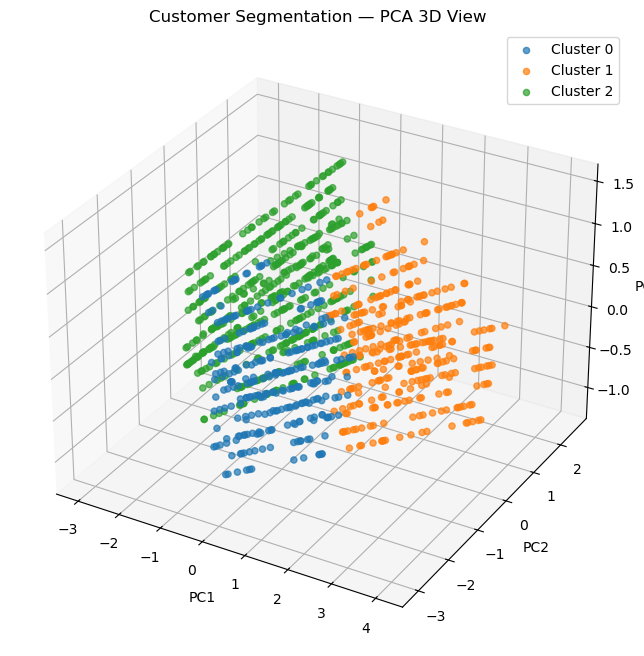

3D PCA explained variance: [0.56583157 0.32255633 0.09621525]
3D total explained variance: 0.9846


In [49]:
# Optional 3D PCA plot.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in sorted(df['Cluster'].unique()):
    mask = df['Cluster'].to_numpy() == cluster
    ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
               label=f'Cluster {cluster}', alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Customer Segmentation — PCA 3D View')
ax.legend()
plt.show()

print('3D PCA explained variance:', pca3.explained_variance_ratio_)
print('3D total explained variance:', round(pca3.explained_variance_ratio_.sum(), 4))


## Step 16 — Export the final segmented dataset

The exported CSV contains the original dataset plus the K-Means cluster label, so it can be reused for reporting or dashboard work.

In [50]:
# Save the final customer segmentation result.
output_file = 'customer_segmentation_results.csv'
df.to_csv(output_file, index=False)

print(f'Saved: {output_file}')
display(df.head())


Saved: customer_segmentation_results.csv


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Cluster
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,1
